In [2]:
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

sample_path = Path(
    "../data/processed/AD_1_LS/AD_1_LS"
)

adata = sc.read_10x_h5(
    sample_path / "filtered_feature_bc_matrix.h5"
)

adata.var_names_make_unique()

print(adata)
print("Number of spots:", adata.n_obs)
print("Number of genes:", adata.n_vars)

AnnData object with n_obs × n_vars = 188 × 21587
    var: 'gene_ids', 'feature_types', 'genome'
Number of spots: 188
Number of genes: 21587


c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


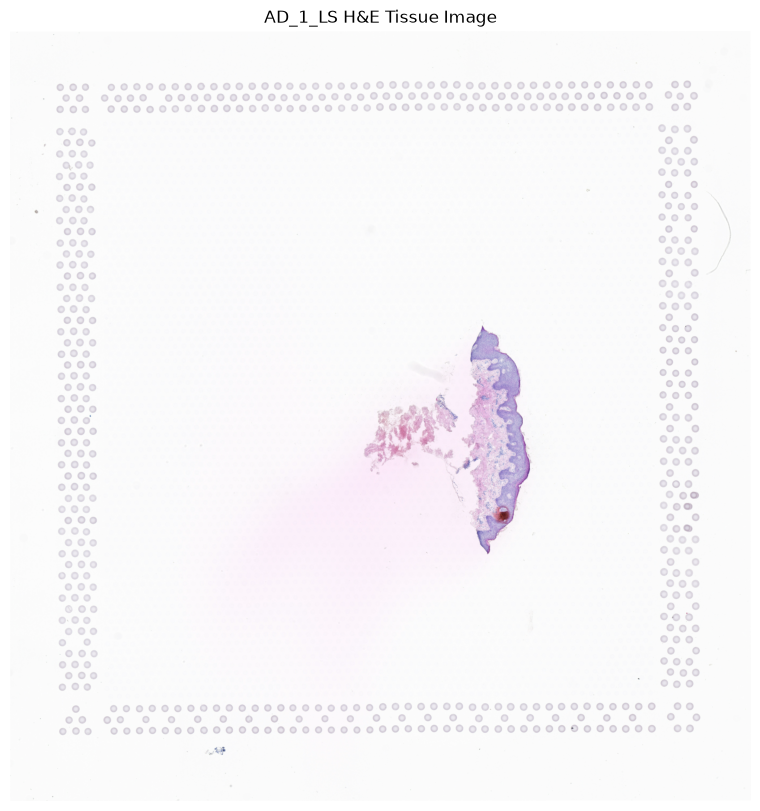

In [3]:
from PIL import Image

image_path = sample_path / "spatial/tissue_hires_image.png"

img = Image.open(image_path)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.title("AD_1_LS H&E Tissue Image")
plt.show()

In [4]:
# Basic dataset information

print("Dataset shape:", adata.shape)

print("\nSample information:")
print(adata.obs.head())

print("\nGene information:")
print(adata.var.head())

print("\nTotal counts per spot:")
print(adata.X.sum(axis=1)[:10])

Dataset shape: (188, 21587)

Sample information:
Empty DataFrame
Columns: []
Index: [AAAGTGTGATTTATCT-1, AAAGTTGACTCCCGTA-1, AACACACGCTCGCCGC-1, AACCCTACTGTCAATA-1, AACCGCTAAGGGATGC-1]

Gene information:
               gene_ids    feature_types  \
OR4F5   ENSG00000186092  Gene Expression   
OR4F29  ENSG00000284733  Gene Expression   
OR4F16  ENSG00000284662  Gene Expression   
SAMD11  ENSG00000187634  Gene Expression   
NOC2L   ENSG00000188976  Gene Expression   

                                                   genome  
OR4F5   genes_10XGEX_SC_Mt_rRNA-Mt_tRNA-protein_coding...  
OR4F29  genes_10XGEX_SC_Mt_rRNA-Mt_tRNA-protein_coding...  
OR4F16  genes_10XGEX_SC_Mt_rRNA-Mt_tRNA-protein_coding...  
SAMD11  genes_10XGEX_SC_Mt_rRNA-Mt_tRNA-protein_coding...  
NOC2L   genes_10XGEX_SC_Mt_rRNA-Mt_tRNA-protein_coding...  

Total counts per spot:
[[42594.]
 [54693.]
 [42126.]
 [39266.]
 [19942.]
 [32418.]
 [24183.]
 [18372.]
 [ 3406.]
 [ 3456.]]


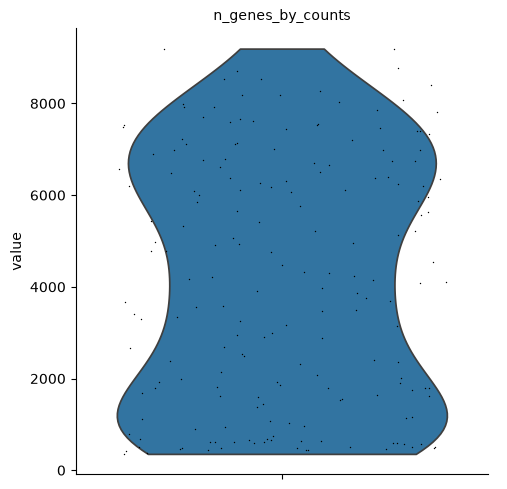

In [5]:
# Calculate quality metrics
sc.pp.calculate_qc_metrics(
    adata,
    inplace=True
)

# Plot number of detected genes per spot
sc.pl.violin(
    adata,
    ["n_genes_by_counts"],
    jitter=0.4,
    multi_panel=True
)

In [6]:
import pandas as pd

positions_path = sample_path / "spatial/tissue_positions_list.csv"

positions = pd.read_csv(
    positions_path,
    header=None
)

positions.head()

,0,1,2,3,4,5
0,ACGCCTGACACGCGCT-1,0,0,0,1192,1245
1,TACCGATCCAACACTT-1,0,1,1,1288,1300
2,ATTAAAGCGGACGAGC-1,0,0,2,1191,1355
3,GATAAGGGACGATTAG-1,0,1,3,1287,1411
4,GTGCAAATCACCAATA-1,0,0,4,1191,1466


In [7]:
# Name the coordinate columns
positions.columns = [
    "barcode",
    "in_tissue",
    "array_row",
    "array_col",
    "pixel_row",
    "pixel_col"
]

# Use barcode as the index
positions = positions.set_index("barcode")

# Match coordinates to our expression spots
spatial_info = positions.loc[
    adata.obs_names.intersection(positions.index)
].copy()

# Keep only matching spots in the expression data
adata = adata[
    adata.obs_names.isin(spatial_info.index)
].copy()

# Reorder coordinates to match adata
spatial_info = spatial_info.loc[adata.obs_names]

# Add spatial information to AnnData
adata.obs = spatial_info

print("Updated dataset:", adata.shape)
print(adata.obs.head())

Updated dataset: (188, 21587)
                    in_tissue  array_row  array_col  pixel_row  pixel_col
AAAGTGTGATTTATCT-1          1         44         94       5409       6476
AAAGTTGACTCCCGTA-1          1         42         96       5215       6586
AACACACGCTCGCCGC-1          1         51         93       6084       6424
AACCCTACTGTCAATA-1          1         40         96       5022       6585
AACCGCTAAGGGATGC-1          1         46         92       5602       6366


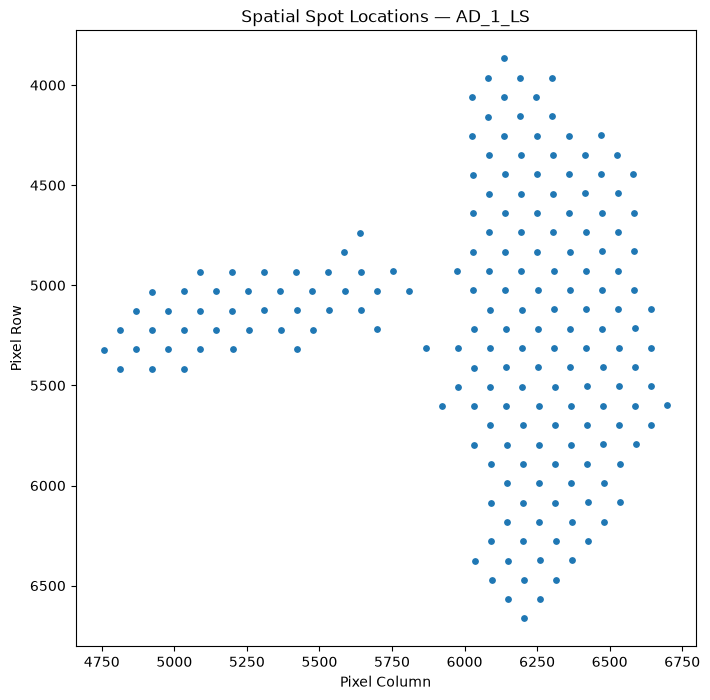

In [8]:
plt.figure(figsize=(8, 8))

plt.scatter(
    adata.obs["pixel_col"],
    adata.obs["pixel_row"],
    s=15
)

plt.gca().invert_yaxis()
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.title("Spatial Spot Locations — AD_1_LS")
plt.show()

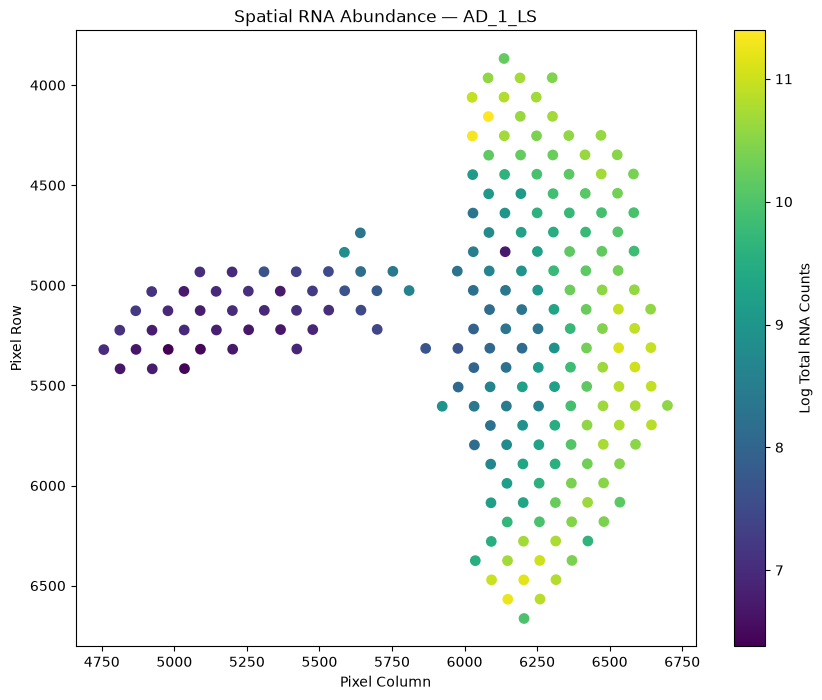

In [9]:
import numpy as np
from scipy.sparse import issparse

# Convert expression matrix to a usable format
total_counts = np.asarray(
    adata.X.sum(axis=1)
).flatten()

# Plot total RNA counts across spatial locations
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    adata.obs["pixel_col"],
    adata.obs["pixel_row"],
    c=np.log1p(total_counts),
    cmap="viridis",
    s=45
)

plt.gca().invert_yaxis()
plt.colorbar(scatter, label="Log Total RNA Counts")
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.title("Spatial RNA Abundance — AD_1_LS")
plt.show()

In [10]:
# Display the first 20 gene names
print(list(adata.var_names[:20]))

# Search for selected skin-related genes
genes_to_check = ["KRT14", "KRT5", "KRT10", "IL13", "IL4", "FLG"]

for gene in genes_to_check:
    matches = [
        name for name in adata.var_names
        if name.upper() == gene
    ]
    print(gene, "->", matches)
    

['OR4F5', 'OR4F29', 'OR4F16', 'SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1', 'HES4', 'ISG15', 'AGRN', 'RNF223', 'C1orf159', 'TTLL10', 'TNFRSF18', 'TNFRSF4', 'SDF4', 'B3GALT6', 'C1QTNF12', 'UBE2J2']
KRT14 -> ['KRT14']
KRT5 -> ['KRT5']
KRT10 -> ['KRT10']
IL13 -> ['IL13']
IL4 -> ['IL4']
FLG -> ['FLG']


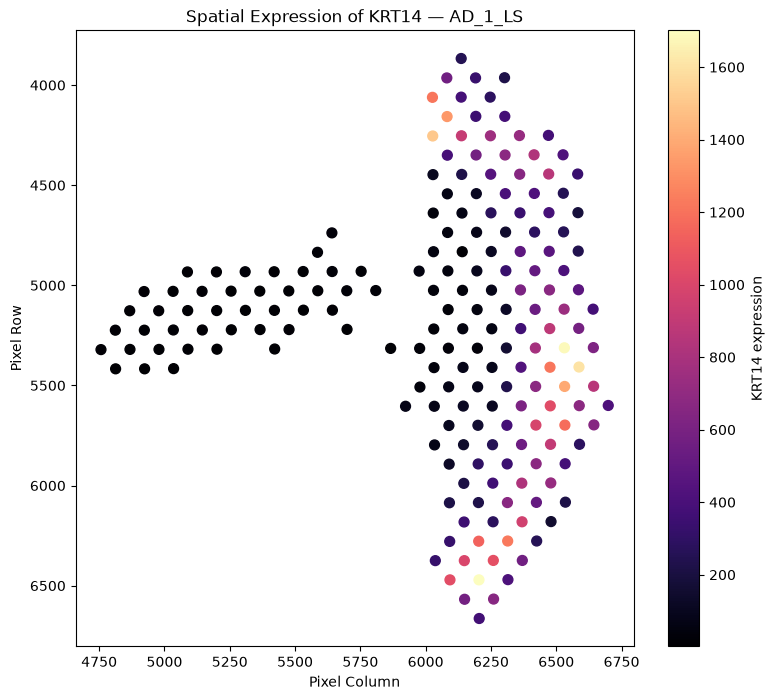

In [11]:
# Function to plot expression of a gene across spatial spots

def plot_gene_expression(gene):
    gene_index = adata.var_names.get_loc(gene)

    expression = adata.X[:, gene_index]

    if hasattr(expression, "toarray"):
        expression = expression.toarray().flatten()
    else:
        expression = np.asarray(expression).flatten()

    plt.figure(figsize=(9, 8))

    scatter = plt.scatter(
        adata.obs["pixel_col"],
        adata.obs["pixel_row"],
        c=expression,
        cmap="magma",
        s=50
    )

    plt.gca().invert_yaxis()
    plt.colorbar(scatter, label=f"{gene} expression")
    plt.xlabel("Pixel Column")
    plt.ylabel("Pixel Row")
    plt.title(f"Spatial Expression of {gene} — AD_1_LS")
    plt.show()

# Plot a skin-related gene
plot_gene_expression("KRT14")

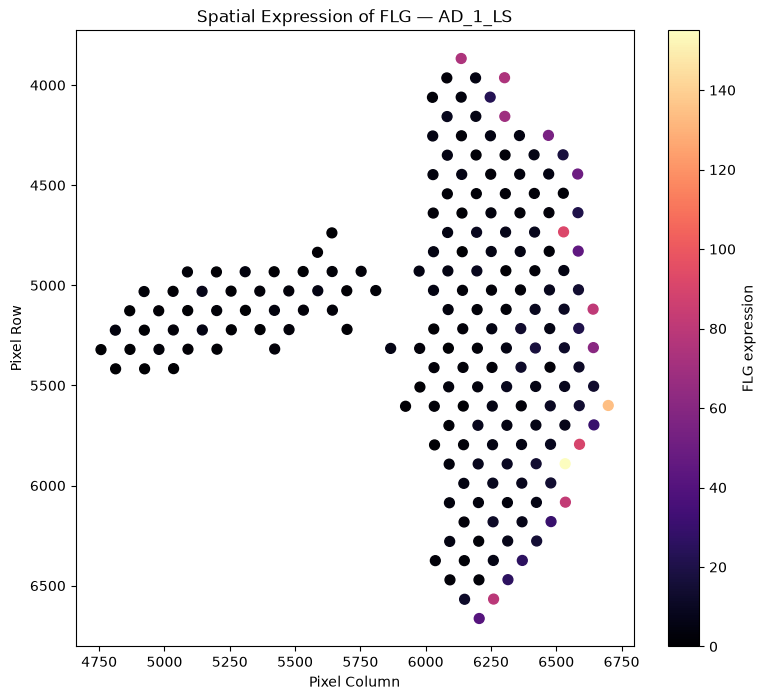

In [12]:
plot_gene_expression("FLG")

In [13]:
def plot_gene_on_hne(gene):
    gene_index = adata.var_names.get_loc(gene)

    expression = adata.X[:, gene_index]

    if hasattr(expression, "toarray"):
        expression = expression.toarray().flatten()
    else:
        expression = np.asarray(expression).flatten()

    # Load H&E image
    img = Image.open(
        sample_path / "spatial/tissue_hires_image.png"
    )

    plt.figure(figsize=(12, 10))

    # Display H&E image
    plt.imshow(img)

    # Overlay spatial gene expression
    scatter = plt.scatter(
        adata.obs["pixel_col"],
        adata.obs["pixel_row"],
        c=expression,
        cmap="magma",
        s=45,
        alpha=0.8
    )

    plt.colorbar(scatter, label=f"{gene} expression")
    plt.title(f"{gene} Expression Overlay — AD_1_LS")
    plt.axis("off")
    plt.show()

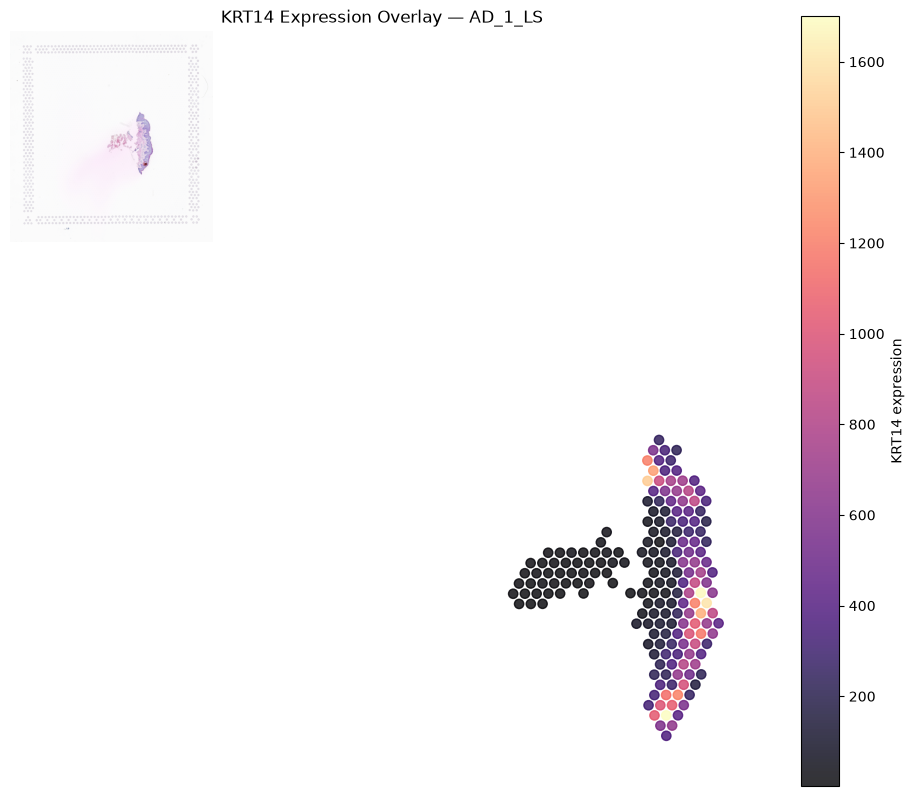

In [14]:
plot_gene_on_hne("KRT14")

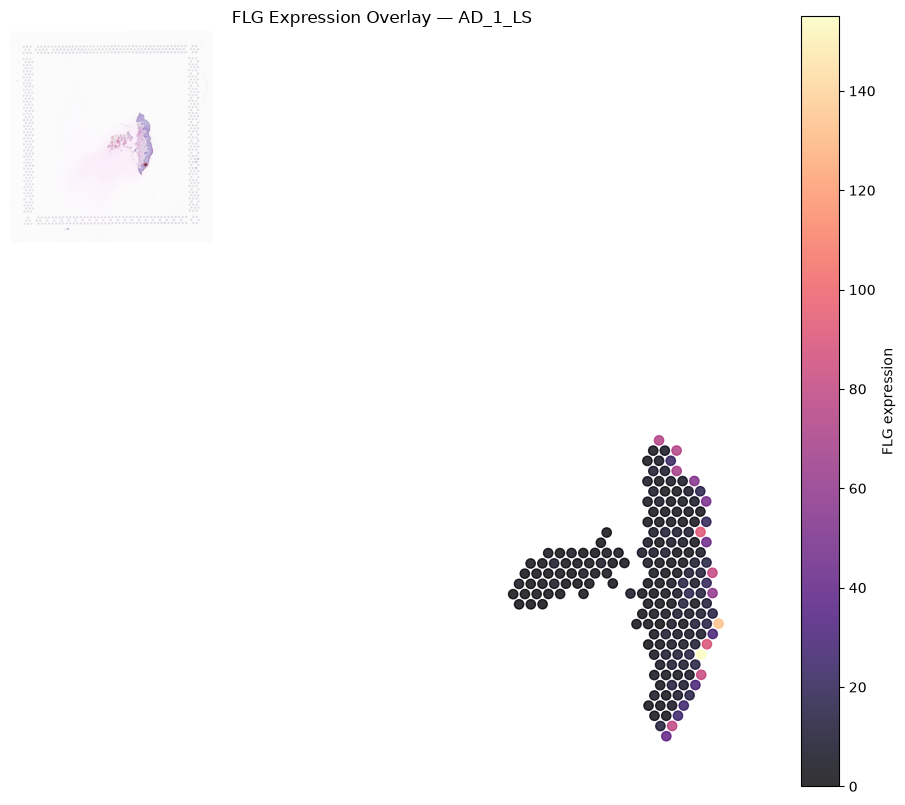

In [15]:
plot_gene_on_hne("FLG")


In [16]:
import json

# Load scale factors
scale_path = sample_path / "spatial/scalefactors_json.json"

with open(scale_path, "r") as f:
    scalefactors = json.load(f)

print(scalefactors)

{'spot_diameter_fullres': 72.05252, 'tissue_hires_scalef': 0.2, 'fiducial_diameter_fullres': 116.39252999999998, 'tissue_lowres_scalef': 0.06}


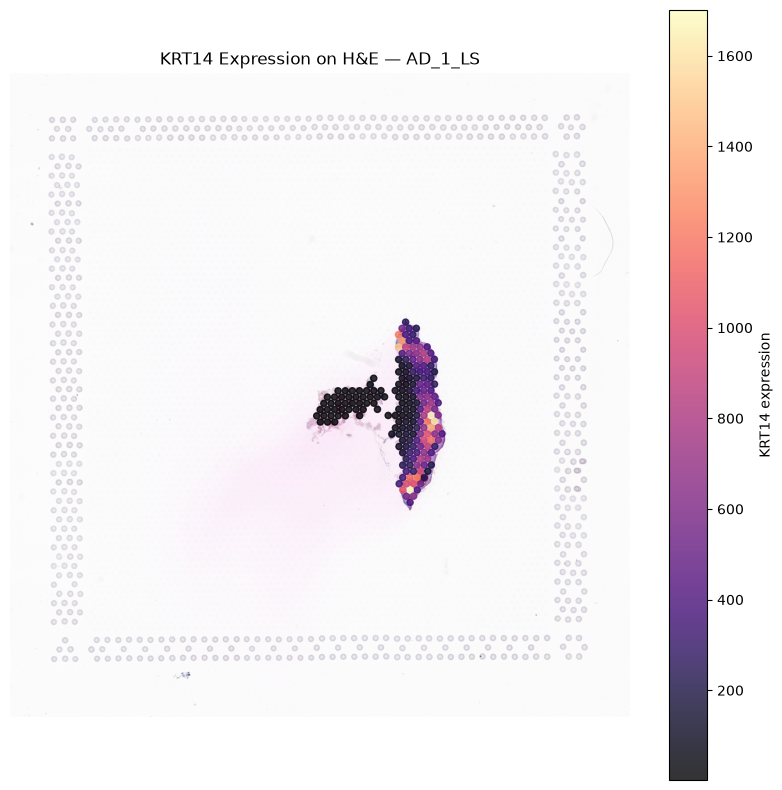

In [17]:
# Scale full-resolution coordinates to H&E image coordinates

scale = scalefactors["tissue_hires_scalef"]

x_scaled = adata.obs["pixel_col"] * scale
y_scaled = adata.obs["pixel_row"] * scale

def plot_gene_on_hne_corrected(gene):
    gene_index = adata.var_names.get_loc(gene)

    expression = adata.X[:, gene_index]

    if hasattr(expression, "toarray"):
        expression = expression.toarray().flatten()
    else:
        expression = np.asarray(expression).flatten()

    img = Image.open(
        sample_path / "spatial/tissue_hires_image.png"
    )

    plt.figure(figsize=(10, 10))
    plt.imshow(img)

    scatter = plt.scatter(
        x_scaled,
        y_scaled,
        c=expression,
        cmap="magma",
        s=20,
        alpha=0.8
    )

    plt.colorbar(scatter, label=f"{gene} expression")
    plt.title(f"{gene} Expression on H&E — AD_1_LS")
    plt.axis("off")
    plt.show()

plot_gene_on_hne_corrected("KRT14")

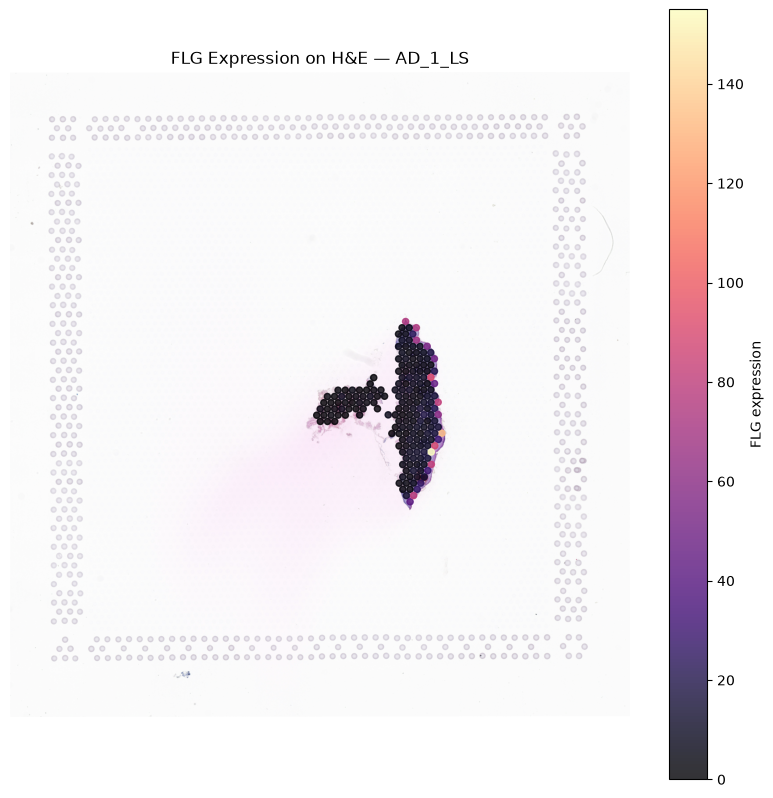

In [18]:
plot_gene_on_hne_corrected("FLG")

In [19]:
# Create output folders
from pathlib import Path

figures_path = Path("../outputs/figures")
results_path = Path("../outputs/results")

figures_path.mkdir(parents=True, exist_ok=True)
results_path.mkdir(parents=True, exist_ok=True)

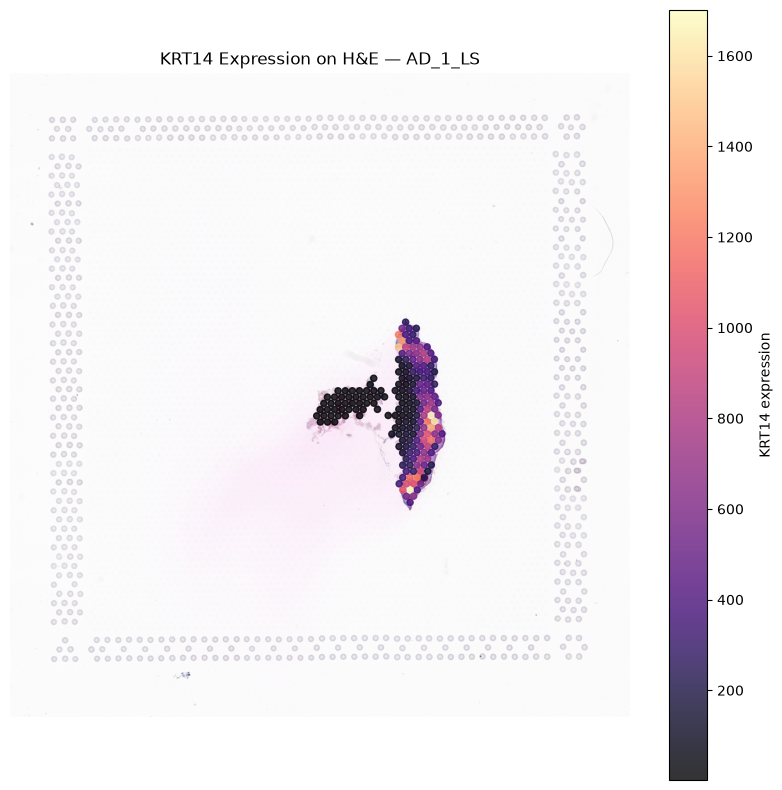

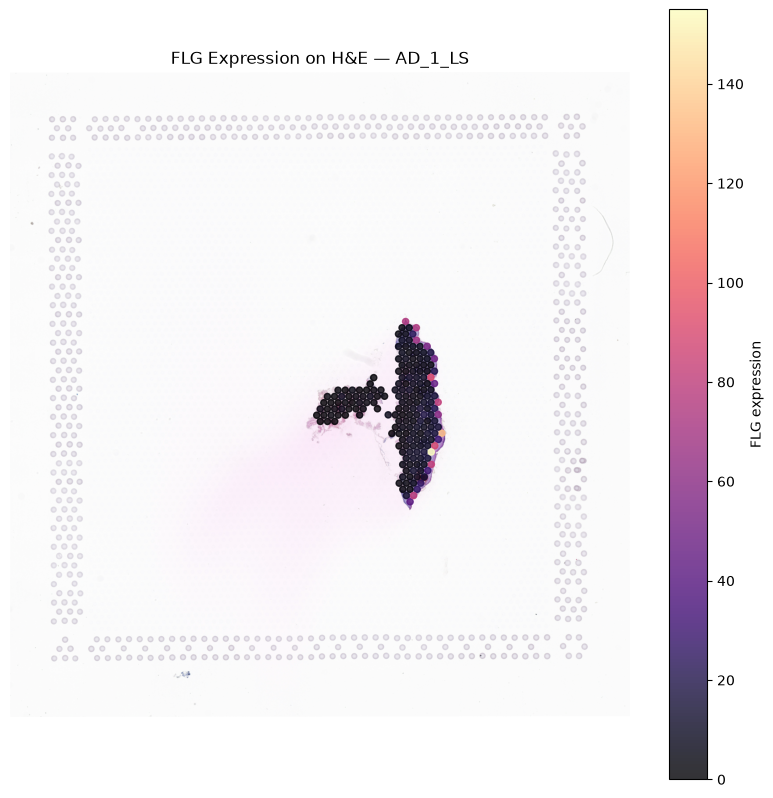

In [20]:
def save_gene_overlay(gene, filename):
    gene_index = adata.var_names.get_loc(gene)
    expression = adata.X[:, gene_index]

    if hasattr(expression, "toarray"):
        expression = expression.toarray().flatten()
    else:
        expression = np.asarray(expression).flatten()

    img = Image.open(
        sample_path / "spatial/tissue_hires_image.png"
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(img)

    scatter = ax.scatter(
        x_scaled,
        y_scaled,
        c=expression,
        cmap="magma",
        s=20,
        alpha=0.8
    )

    fig.colorbar(scatter, ax=ax, label=f"{gene} expression")
    ax.set_title(f"{gene} Expression on H&E — AD_1_LS")
    ax.axis("off")

    fig.savefig(
        figures_path / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

save_gene_overlay("KRT14", "AD1_KRT14_overlay.png")
save_gene_overlay("FLG", "AD1_FLG_overlay.png")

In [21]:
adata.write_h5ad(
    results_path / "AD_1_LS_processed.h5ad"
)

print("Results saved successfully!")

Results saved successfully!


In [22]:
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "data" / "processed"

SAMPLE_IDS = [
    "AD_1_LS",
    "AD_2_LS",
    "AD_3_LS",
    "AD_4_LS"
]

datasets = {}

for sample_id in SAMPLE_IDS:

    print(f"\nLoading {sample_id}...")

    # Extracted sample directory
    sample_path = DATA_ROOT / sample_id / sample_id

    # File paths
    h5_path = sample_path / "filtered_feature_bc_matrix.h5"
    spatial_path = sample_path / "spatial"
    image_path = spatial_path / "tissue_hires_image.png"
    positions_path = spatial_path / "tissue_positions_list.csv"

    # Validate required files
    required_files = [
        h5_path,
        image_path,
        positions_path
    ]

    for file_path in required_files:
        if not file_path.exists():
            raise FileNotFoundError(
                f"Missing file for {sample_id}: {file_path}"
            )

    # Load gene expression data
    adata = sc.read_10x_h5(
        h5_path,
        genome=None
    )

    # Ensure unique gene names
    adata.var_names_make_unique()

    # Add sample metadata
    adata.obs["sample_id"] = sample_id
    adata.obs["condition"] = "AD_lesional"

    # Load spatial spot positions
    positions = pd.read_csv(
        positions_path,
        header=None
    )

    positions.columns = [
        "barcode",
        "in_tissue",
        "array_row",
        "array_col",
        "pixel_row",
        "pixel_col"
    ]

    positions = positions.set_index("barcode")

    # Keep only barcodes present in expression data
    common_barcodes = adata.obs_names.intersection(
        positions.index
    )

    adata = adata[common_barcodes].copy()
    positions = positions.loc[common_barcodes]

    # Add spatial metadata to observations
    adata.obs = adata.obs.join(
        positions,
        how="left"
    )

    # Load H&E image
    image = Image.open(image_path)

    # Store dataset information
    datasets[sample_id] = {
        "adata": adata,
        "image": image,
        "positions": positions
    }

    print(f"Spots: {adata.n_obs}")
    print(f"Genes: {adata.n_vars}")
    print(f"Image size: {image.size}")

print("\nAll samples loaded successfully!")


Loading AD_1_LS...


c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Spots: 188
Genes: 21587
Image size: (1924, 2000)

Loading AD_2_LS...


c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Spots: 335
Genes: 21587
Image size: (2000, 2000)

Loading AD_3_LS...


c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Spots: 791
Genes: 21587
Image size: (2000, 1992)

Loading AD_4_LS...


c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Manya Aggarwal\OneDrive\Desktop\spatial-tissue-profiling\rpvenv\Lib\site-packages\anndata\_core\anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Spots: 1177
Genes: 21587
Image size: (2000, 1996)

All samples loaded successfully!
